
Initial Swarm
Particle |         x1 |         x2 |         v1 |         v2 |        fitness
--------------------------------------------------------------------------------
       1 |     1.3943 |    -4.7499 |     0.0000 |     0.0000 |      4480.9526
       2 |    -2.2497 |    -2.7679 |     0.0000 |     0.0000 |      6139.9996
       3 |     2.3647 |     1.7670 |     0.0000 |     0.0000 |      1464.8244
       4 |     3.9218 |    -4.1306 |     0.0000 |     0.0000 |     38076.8119
       5 |    -0.7808 |    -4.7020 |     0.0000 |     0.0000 |      2824.5317
       6 |    -2.8136 |     0.0536 |     0.0000 |     0.0000 |      6197.0728
       7 |    -4.7346 |    -3.0116 |     0.0000 |     0.0000 |     64693.4538
       8 |     1.4988 |     0.4494 |     0.0000 |     0.0000 |       323.2128
       9 |    -2.7956 |     0.8927 |     0.0000 |     0.0000 |      4806.7671
      10 |     3.0943 |    -4.9350 |     0.0000 |     0.0000 |     21057.6217
      11 |     3.0582 |     1.9814 |     0.000

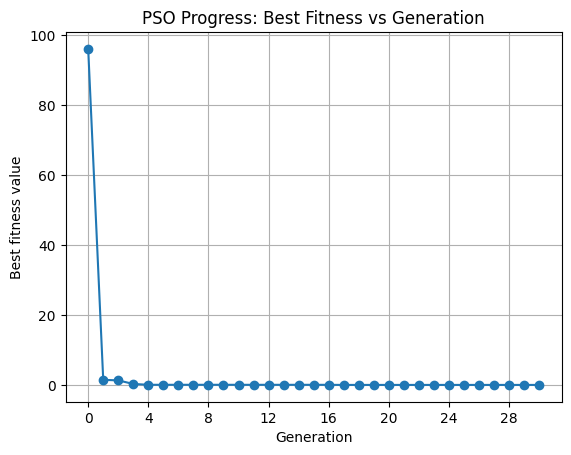

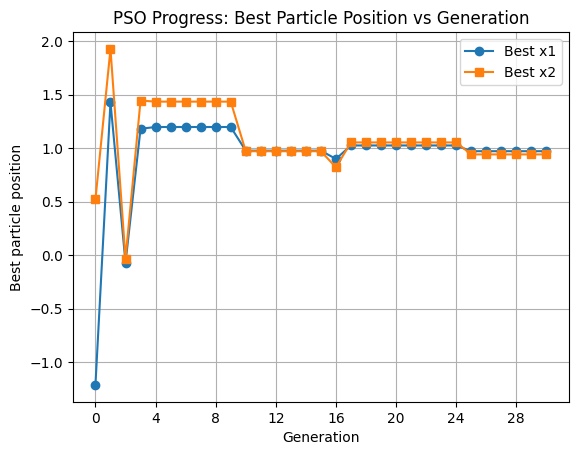

In [1]:

# ============================================================
# Particle Swarm Optimization (PSO) using DEAP
# Problem: Minimize Rosenbrock function
#
# Rosenbrock function:
# f(x1, x2) = 100(x2 - x1^2)^2 + (1 - x1)^2
#
# Global optimum:
# x1 = 1, x2 = 1
# f(x) = 0
# ============================================================


# ------------------------------------------------------------
# Import required libraries
# ------------------------------------------------------------

import random
#!pip install deap                    # For random numbers used in PSO
import matplotlib.pyplot as plt     # For plotting convergence graphs
from matplotlib.ticker import MaxNLocator  # To show integer generation numbers
from deap import base, creator, tools       # DEAP components


# ------------------------------------------------------------
# 1) Basic problem and algorithm settings
# ------------------------------------------------------------

# Fix random seed so that the same random numbers are generated every time.
# This is useful for teaching because students can reproduce the same output.
random.seed(42)

# Number of design variables.
# Here Rosenbrock has two variables: x1 and x2.
NDIM = 2

# Lower and upper bounds for both variables.
# So both x1 and x2 will remain between -5 and +5.
LOW = -5.0
UP = 5.0

# Number of particles in the swarm.
# In PSO, population is called swarm.
SWARM_SIZE = 50

# Number of generations or iterations.
NGEN = 30


# ------------------------------------------------------------
# 2) PSO control parameters
# ------------------------------------------------------------

# Inertia weight.
# It controls how much of the previous velocity is retained.
W = 0.75

# Cognitive coefficient.
# It controls attraction toward the particle's own best position.
C1 = 1.5

# Social coefficient.
# It controls attraction toward the global best position.
C2 = 2.0

# Minimum and maximum velocity allowed.
# These limits avoid very large jumps.
VMIN = -2.0
VMAX = 2.0


# ------------------------------------------------------------
# 3) Objective function
# ------------------------------------------------------------

def rosenbrock(particle):
    """
    Evaluate the Rosenbrock function for one particle.

    A particle is simply a list:
        particle = [x1, x2]

    The function returns a tuple because DEAP expects fitness in tuple form.
    """

    # Extract x1 and x2 from the particle
    x1, x2 = particle

    # Calculate Rosenbrock function value
    value = 100.0 * (x2 - x1**2)**2 + (1.0 - x1)**2

    # DEAP requires a tuple, even for a single objective.
    # So we return (value,) instead of only value.
    return (value,)


# ------------------------------------------------------------
# 4) Create DEAP fitness and particle classes
# ------------------------------------------------------------

# Create a fitness class for minimization.
# weights=(-1.0,) tells DEAP that smaller fitness is better.
#
# The if-condition avoids error if the code is run again in the same session.
if not hasattr(creator, "FitnessMinPSO"):
    creator.create("FitnessMinPSO", base.Fitness, weights=(-1.0,))


# Create a particle class.
#
# A particle is basically a list, for example:
#     [x1, x2]
#
# But we attach extra attributes to it:
#     fitness -> objective function value
#     speed   -> velocity vector [v1, v2]
#     best    -> personal best position of this particle
if not hasattr(creator, "ParticlePSO"):
    creator.create(
        "ParticlePSO",
        list,
        fitness=creator.FitnessMinPSO,
        speed=list,
        best=None
    )


# ------------------------------------------------------------
# 5) Function to generate one particle
# ------------------------------------------------------------

def generate_particle():
    """
    Generate one particle.

    Each particle has:
    1. random position within bounds
    2. initial velocity equal to zero
    3. personal best initially set to None
    """

    # Randomly initialize position.
    # Since NDIM = 2, two random values are generated.
    particle = creator.ParticlePSO(
        random.uniform(LOW, UP) for _ in range(NDIM)
    )

    # Initial velocity is zero for both variables.
    # For two variables:
    #     speed = [0.0, 0.0]
    particle.speed = [0.0 for _ in range(NDIM)]

    # Personal best is not known until the particle is evaluated.
    particle.best = None

    return particle


# ------------------------------------------------------------
# 6) Function to copy a particle
# ------------------------------------------------------------

def copy_particle(particle):
    """
    Make a copy of a particle.

    This is important because pbest and gbest should store old best positions.
    If we do not copy, they may change when the particle moves.
    """

    # Copy the position values
    new_particle = creator.ParticlePSO(particle[:])

    # Copy the velocity values
    new_particle.speed = particle.speed[:]

    # This copied particle does not need its own personal best
    new_particle.best = None

    # If the original particle already has fitness,
    # copy the fitness value also.
    if particle.fitness.valid:
        new_particle.fitness.values = particle.fitness.values

    return new_particle


# ------------------------------------------------------------
# 7) PSO velocity and position update
# ------------------------------------------------------------

def update_particle(particle, global_best):
    """
    Update velocity and position of one particle.

    PSO velocity equation:

    v = wv + c1*r1*(pbest - x) + c2*r2*(gbest - x)

    where:
    w  = inertia weight
    c1 = cognitive coefficient
    c2 = social coefficient
    r1, r2 = random numbers between 0 and 1

    Position update:

    x = x + v
    """

    # Update each variable separately.
    # For Rosenbrock, this loop runs for:
    # i = 0 -> x1
    # i = 1 -> x2
    for i in range(NDIM):

        # Random numbers for cognitive and social terms
        r1 = random.random()
        r2 = random.random()

        # ----------------------------------------------------
        # Inertia term:
        # Keeps part of the previous velocity
        # ----------------------------------------------------
        inertia = W * particle.speed[i]

        # ----------------------------------------------------
        # Cognitive term:
        # Pulls the particle toward its own best position
        # ----------------------------------------------------
        cognitive = C1 * r1 * (particle.best[i] - particle[i])

        # ----------------------------------------------------
        # Social term:
        # Pulls the particle toward the global best position
        # ----------------------------------------------------
        social = C2 * r2 * (global_best[i] - particle[i])

        # ----------------------------------------------------
        # New velocity
        # ----------------------------------------------------
        new_speed = inertia + cognitive + social

        # ----------------------------------------------------
        # Apply velocity limits
        # ----------------------------------------------------
        if new_speed > VMAX:
            new_speed = VMAX
        elif new_speed < VMIN:
            new_speed = VMIN

        # Store updated velocity
        particle.speed[i] = new_speed

        # ----------------------------------------------------
        # Update position
        # x_new = x_old + v_new
        # ----------------------------------------------------
        particle[i] = particle[i] + particle.speed[i]

        # ----------------------------------------------------
        # Apply position bounds
        # ----------------------------------------------------
        if particle[i] > UP:
            particle[i] = UP
        elif particle[i] < LOW:
            particle[i] = LOW


# ------------------------------------------------------------
# 8) DEAP toolbox
# ------------------------------------------------------------

# Toolbox is a container where we register important functions.
toolbox = base.Toolbox()

# Register particle generator
toolbox.register("particle", generate_particle)

# Register swarm generator.
# It repeatedly calls toolbox.particle to create many particles.
toolbox.register("swarm", tools.initRepeat, list, toolbox.particle)

# Register objective function
toolbox.register("evaluate", rosenbrock)

# Register PSO update function
toolbox.register("update", update_particle)


# ------------------------------------------------------------
# 9) Function to print swarm in table form
# ------------------------------------------------------------

def print_swarm(swarm, title):
    """
    Print the current swarm in a readable table.

    This is not required for PSO itself,
    but it is useful for teaching and demonstration.
    """

    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    # Table header
    print(
        f"{'Particle':>8} | {'x1':>10} | {'x2':>10} | "
        f"{'v1':>10} | {'v2':>10} | {'fitness':>14}"
    )
    print("-" * 80)

    # Print each particle
    for i, p in enumerate(swarm, start=1):
        print(
            f"{i:>8} | {p[0]:>10.4f} | {p[1]:>10.4f} | "
            f"{p.speed[0]:>10.4f} | {p.speed[1]:>10.4f} | "
            f"{p.fitness.values[0]:>14.4f}"
        )


# ------------------------------------------------------------
# 10) Create initial swarm
# ------------------------------------------------------------

# Create initial swarm of SWARM_SIZE particles
swarm = toolbox.swarm(n=SWARM_SIZE)


# ------------------------------------------------------------
# 11) Evaluate initial swarm and set personal bests
# ------------------------------------------------------------

for particle in swarm:

    # Evaluate current particle position
    particle.fitness.values = toolbox.evaluate(particle)

    # At the start, the current position is also the personal best.
    # Because the particle has not visited any other position yet.
    particle.best = copy_particle(particle)


# ------------------------------------------------------------
# 12) Find initial global best
# ------------------------------------------------------------

# The global best is the best particle among all particles.
# Since this is minimization, we select the particle with minimum fitness.
global_best = copy_particle(
    min(swarm, key=lambda p: p.fitness.values[0])
)


# ------------------------------------------------------------
# 13) Store history for plotting
# ------------------------------------------------------------

# Generation 0 means before any PSO update.
generations = [0]

# Store best fitness value at each generation
best_fitness_history = [global_best.fitness.values[0]]

# Store best x1 and x2 values at each generation
best_x1_history = [global_best[0]]
best_x2_history = [global_best[1]]


# ------------------------------------------------------------
# 14) Print initial swarm and initial global best
# ------------------------------------------------------------

print_swarm(swarm, "Initial Swarm")

print("\nInitial global best:")
print(f"gbest = [{global_best[0]:.4f}, {global_best[1]:.4f}]")
print(f"f(gbest) = {global_best.fitness.values[0]:.6f}")


# ------------------------------------------------------------
# 15) Main PSO loop
# ------------------------------------------------------------

for gen in range(1, NGEN + 1):

    # --------------------------------------------------------
    # Update each particle in the swarm
    # --------------------------------------------------------
    for particle in swarm:

        # Update velocity and position using PSO equations
        toolbox.update(particle, global_best)

        # Evaluate the new position
        particle.fitness.values = toolbox.evaluate(particle)

        # ----------------------------------------------------
        # Update personal best
        # ----------------------------------------------------
        # If current position is better than previous personal best,
        # replace personal best with the current position.
        if particle.fitness.values[0] < particle.best.fitness.values[0]:
            particle.best = copy_particle(particle)

    # --------------------------------------------------------
    # Update global best
    # --------------------------------------------------------

    # Find the particle with the best personal best
    best_particle = min(swarm, key=lambda p: p.best.fitness.values[0])

    # If this best personal best is better than current global best,
    # update global best.
    if best_particle.best.fitness.values[0] < global_best.fitness.values[0]:
        global_best = copy_particle(best_particle.best)

    # --------------------------------------------------------
    # Store progress for plotting
    # --------------------------------------------------------
    generations.append(gen)
    best_fitness_history.append(global_best.fitness.values[0])
    best_x1_history.append(global_best[0])
    best_x2_history.append(global_best[1])

    # --------------------------------------------------------
    # Print best result of this generation
    # --------------------------------------------------------
    print(f"\nGeneration {gen}")
    print(f"Best position = [{global_best[0]:.4f}, {global_best[1]:.4f}]")
    print(f"Best fitness  = {global_best.fitness.values[0]:.6f}")


# ------------------------------------------------------------
# 16) Final result
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("Final Best Solution")
print("=" * 80)
print(f"x = [{global_best[0]:.6f}, {global_best[1]:.6f}]")
print(f"f(x) = {global_best.fitness.values[0]:.6f}")


# ------------------------------------------------------------
# 17) Plot best fitness versus generation
# ------------------------------------------------------------

plt.figure()

# Plot best fitness value against generation number
plt.plot(generations, best_fitness_history, marker='o')

plt.xlabel("Generation")
plt.ylabel("Best fitness value")
plt.title("PSO Progress: Best Fitness vs Generation")
plt.grid(True)

# Force x-axis to show integer generation numbers only
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()


# ------------------------------------------------------------
# 18) Plot best particle position versus generation
# ------------------------------------------------------------

plt.figure()

# Plot x1 and x2 values of the global best particle
plt.plot(generations, best_x1_history, marker='o', label="Best x1")
plt.plot(generations, best_x2_history, marker='s', label="Best x2")

plt.xlabel("Generation")
plt.ylabel("Best particle position")
plt.title("PSO Progress: Best Particle Position vs Generation")
plt.legend()
plt.grid(True)

# Force x-axis to show integer generation numbers only
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()